In [1]:
# In this notebook you'll learn to use SkTime to predict PM2.5 using endog and exog variables.
# Environmental data from https://aqicn.org/historical/#city:ireland/finglas--dublin-11
# Steps:
# 1. Data preparation: set date time column, index, imputations, etc
# 2. Create a model using Prophet (using PM2.5 as endog variable)
# 3. Create a model using AutoARIMA (using PM2.5 as endog + other columns as exog variables)
#
# Relevant link:
#   https://www.sktime.net/en/stable/examples/01_forecasting.html

In [2]:
from pandas import to_datetime
from pandas import read_csv, to_numeric
from numpy import array

from sktime.forecasting.compose import ForecastX
from sktime.forecasting.fbprophet import Prophet
from sktime.forecasting.statsforecast import StatsForecastAutoARIMA

In [3]:
# Open sample data, clean up the column names, force certain columns to be numeric & set index with daily frequency
df = read_csv('finglas,-dublin 11-air-quality.csv')    # load some timeseries data

df.columns = df.columns.str.strip()     # clean up extra spaces in the column header
df[['pm25', 'pm10']] = df[['pm25', 'pm10']].apply(to_numeric, errors='coerce')

# Prepare datetime column as index
df.drop_duplicates(subset=['date'])
df['date'] = to_datetime(df['date'], format='%Y/%m/%d')
df = df.set_index('date', drop=False, verify_integrity=True)
df = df.asfreq('D')

df.head()

,date,pm25,pm10
date,,,
2021-02-18,2021-02-18,NaN,8.0
2021-02-19,2021-02-19,19.0,6.0
2021-02-20,2021-02-20,15.0,11.0
2021-02-21,2021-02-21,33.0,10.0
2021-02-22,2021-02-22,25.0,11.0


In [4]:
# Only PM2.5 and PM10? Let's create one more columns...

df['month'] = df.index.month        # 1-12
df['weekend'] = array(df.index.weekday>4).astype(int)       # 5 for Saturday, 6 for Sunday
df.head()

,date,pm25,pm10,month,weekend
date,,,,,
2021-02-18,2021-02-18,NaN,8.0,2,0
2021-02-19,2021-02-19,19.0,6.0,2,0
2021-02-20,2021-02-20,15.0,11.0,2,1
2021-02-21,2021-02-21,33.0,10.0,2,1
2021-02-22,2021-02-22,25.0,11.0,2,0


In [5]:
# We have lots of missing values.
df.isnull().sum()

date       22
pm25       31
pm10       31
month       0
weekend     0
dtype: int64

In [6]:
# impute missing numerical values using linear interpolation
df = df.interpolate()
df.head()

,date,pm25,pm10,month,weekend
date,,,,,
2021-02-18,2021-02-18,NaN,8.0,2,0
2021-02-19,2021-02-19,19.0,6.0,2,0
2021-02-20,2021-02-20,15.0,11.0,2,1
2021-02-21,2021-02-21,33.0,10.0,2,1
2021-02-22,2021-02-22,25.0,11.0,2,0


In [7]:
df.bfill(inplace=True)          # backward fill that NaN
df.head()

,date,pm25,pm10,month,weekend
date,,,,,
2021-02-18,2021-02-18,19.0,8.0,2,0
2021-02-19,2021-02-19,19.0,6.0,2,0
2021-02-20,2021-02-20,15.0,11.0,2,1
2021-02-21,2021-02-21,33.0,10.0,2,1
2021-02-22,2021-02-22,25.0,11.0,2,0


In [8]:
# re-count missing values. Looks good.
df.isnull().sum()

date       0
pm25       0
pm10       0
month      0
weekend    0
dtype: int64

In [9]:
# Decide a target variable. Let's say we take PM2.5

y = df['pm25']
X = df[['pm10', 'month', 'weekend']]

fh = [1,2,3,4,5,6,7]        # forecast next week
sp = 7                      # Weekly seasonal periodicity (any other guess?)

In [10]:
[y.head(), X.head()]

[date
 2021-02-18    19.0
 2021-02-19    19.0
 2021-02-20    15.0
 2021-02-21    33.0
 2021-02-22    25.0
 Freq: D, Name: pm25, dtype: float64,
             pm10  month  weekend
 date                            
 2021-02-18   8.0      2        0
 2021-02-19   6.0      2        0
 2021-02-20  11.0      2        1
 2021-02-21  10.0      2        1
 2021-02-22  11.0      2        0]

In [16]:
# We can include holidays as a component to the model

model = Prophet(
        add_country_holidays={'country_name': 'Ireland'},
        weekly_seasonality=True
    )

model.fit(y)

19:52:10 - cmdstanpy - INFO - Chain [1] start processing
19:52:10 - cmdstanpy - INFO - Chain [1] done processing


Prophet(add_country_holidays={'country_name': 'Ireland'},
        weekly_seasonality=True)

In [12]:
df.tail()

,date,pm25,pm10,month,weekend
date,,,,,
2024-11-30,2024-11-30,23.0,6.0,11,1
2024-12-01,2024-12-01,17.0,5.0,12,1
2024-12-02,2024-12-02,14.0,6.0,12,0
2024-12-03,2024-12-03,17.0,13.0,12,0
2024-12-04,2024-12-04,38.0,13.0,12,0


In [13]:
y_pred = model.predict(fh=fh)
y_pred

2024-12-05    35.816850
2024-12-06    35.629200
2024-12-07    35.688787
2024-12-08    37.448962
2024-12-09    36.704860
2024-12-10    35.834081
2024-12-11    35.932482
Name: pm25, dtype: float64

In [17]:
# We can forecast PM2.5 using exog variables PM10, month, weekend, etc

model = ForecastX(
    forecaster_y=StatsForecastAutoARIMA(sp=sp, biasadj=True, n_jobs=-1),
    forecaster_X=StatsForecastAutoARIMA(sp=sp, biasadj=True, n_jobs=-1),
)

model.fit(y=y, X=X, fh=fh)

C:\Users\tomas\AppData\Roaming\Python\Python312\site-packages\sktime\forecasting\base\adapters\_generalised_statsforecast.py:125: UserWarning: Keyword arguments "num_cores" will be omitted as they are not found in the __init__ method from <class 'statsforecast.models.AutoARIMA'>. Check your statsforecast version to find out the right API parameters.
  warn(warning_message)
C:\Users\tomas\AppData\Roaming\Python\Python312\site-packages\statsforecast\arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
C:\Users\tomas\AppData\Roaming\Python\Python312\site-packages\statsforecast\arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
C:\Users\tomas\AppData\Roaming\Python\Python312\site-packages\statsforecast\arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
C:\Users\tomas\AppData\Roaming\Python\Python312\site-packages\statsforecast\arima.py:486: UserWarning: possi

ForecastX(forecaster_X=StatsForecastAutoARIMA(biasadj=True, n_jobs=-1, sp=7),
          forecaster_y=StatsForecastAutoARIMA(biasadj=True, n_jobs=-1, sp=7))

In [18]:
y_pred = model.predict(fh=fh)
y_pred

2024-12-05    37.929945
2024-12-06    32.731270
2024-12-07    29.146150
2024-12-08    28.943471
2024-12-09    26.256543
2024-12-10    26.216577
2024-12-11    27.085262
Freq: D, Name: pm25, dtype: float64

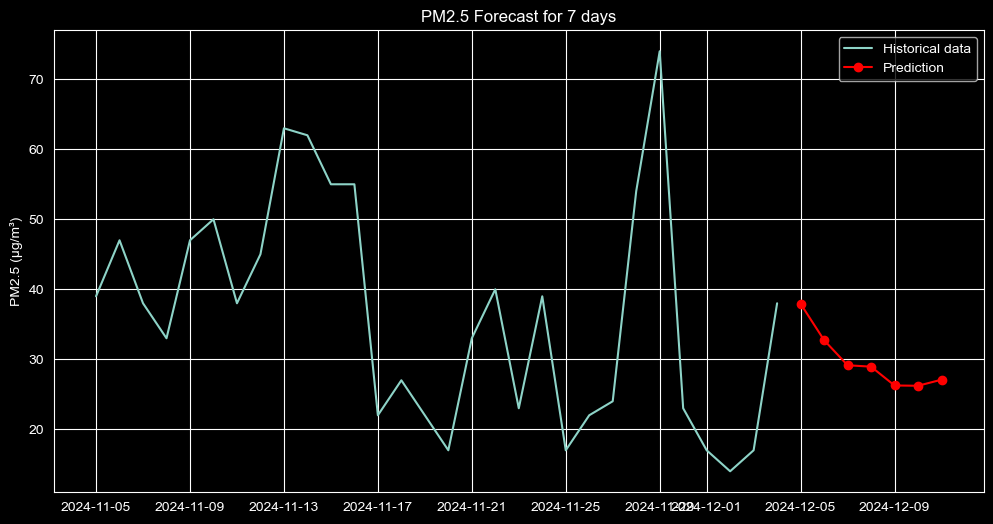

In [20]:
import matplotlib.pyplot as plt

# Prediction plot
plt.figure(figsize=(12, 6))
plt.plot(y.index[-30:], y[-30:], label='Historical data')
plt.plot(y_pred.index, y_pred, 'ro-', label='Prediction')
plt.title('PM2.5 Forecast for 7 days')
plt.ylabel('PM2.5 (μg/m³)')
plt.legend()
plt.grid(True)
plt.show()